# Workshop 3: Interactive Visualisation and Analysis of Copernicus Data

**Course:** Geospatial Processing 

**Lecturer:** Liliana Castillo Villamor 

**Student:** Luis Gabriel Bautista Montealegre 

## 1. Hands-On Project

### Objective
Apply the cloud geospatial data workflow (CDSE, `leafmap`, `rasterio`, and `xarray`) to perform a multi-temporal change detection analysis on a study area of your choice.

---

### Project Guidelines

1. Select a study area relevant to your research project. Load a vector file (`.geojson`, `.gpkg`, or `.shp`) defining your AOI and extract its geometry.

2. Query the CDSE OData API for a specific product of your choice. Select **two distinct acquisition dates** (e.g., dry vs. rainy season, pre- vs. post-extreme event, or interannual comparison).

3. Access the relevant spectral bands directly via S3 using the `/vsis3/` virtual file system without downloading the entire product locally, and mask or clip the datasets to your AOI.
   * Calculate a **difference or change image**  to quantify spatial changes across time.
   * Export the generated difference raster locally as a GeoTIFF file (`.tif` or `.tiff`) using `rasterio` or `rioxarray`, ensuring proper georeferencing and spatial reference system (CRS) preservation.

4. Render the State 1 image, State 2 image, and Difference image on an interactive map using `leafmap` with an appropriate divergent colour palette (e.g., `RdYlGn` or `coolwarm`). Incorporate additional map controls into your `leafmap` interface to enhance usability (e.g., `split_map` / swipe control, layer control, scale bar, minimap, draw control, or full-screen mode).
   * Include a histogram and basic descriptive statistics (mean, min, max, standard deviation) for the pixel difference distribution.

5. Prepare a **5-minute live demonstration** of your findings to present directly to the class. No slide deck is required: you will present your workflow, interactive maps, and spatial insights directly by walking through your executed Jupyter Notebook.

## 0. Study Area: La Palma, Cundinamarca, Colombia

**Study Area:** Municipality of La Palma, Cundinamarca, Colombia.

**Satellite imagery:** Sentinel-2 Level-2A

**Study dates:** State 1: 2017 - State 2: 2024

**Main objective:** To access Sentinel-2 imagery from the Copernicus Data Space Ecosystem (CDSE), clip the imagery to the study area, calculate the spectral change between 2017 and 2024, and visualise the results interactively using Leafmap.

## 1. Environment Setup & Package Dependencies

Before running the workflow, several specialised Python libraries and GDAL drivers must be installed:

**leafmap**: An open-source Python library designed for interactive mapping and geospatial analysis within Jupyter notebooks. It simplifies visualising vector and raster data layers using interactive map backends (such as MapLibre GL).

**localtileserver**: A local tile server package that renders large spatial raster files (such as Cloud Optimised GeoTIFFs) directly onto interactive web maps without requiring prior disk downloads or manual sub-sampling.

**jupyter-server-proxy**: A Jupyter notebook extension that allows web-based applications (such as localtileserver) to run alongside the notebook and proxy HTTP requests securely.

**xarray**: A computational package for working with multi-dimensional labelled arrays, widely used for handling spatio-temporal Earth observation datasets.

**boto3**: The Amazon Web Services (AWS) SDK for Python. It allows programmatic access to S3-compatible cloud storage buckets, such as the Copernicus Data Space Ecosystem (eodata).

**libgdal-jp2openjpeg**: A GDAL plugin library providing engine support for reading JPEG 2000 (.jp2) image formats, which are extensively used across Sentinel-2 satellite products.

In [20]:
# --- Core System & Utility Modules ---

# Import operating system interfaces for managing environment credentials and file paths
import os

# Import regular expressions library for string pattern matching and metadata parsing
import re

# Import HTTP library for making API requests to remote cloud catalogue endpoints
import requests


# --- AWS Cloud Authentication & S3 Interface ---
# Import AWS SDK to interface with Copernicus S3-compatible cloud object storage
import boto3

# Import AWS authentication session handler for GDAL and Rasterio virtual file system (/vsis3/) access
from rasterio.session import AWSSession


# --- Geospatial & Numerical Processing Engines ---
# Import multi-dimensional array computation library for matrix operations and type casting
import numpy as np

# Import geospatial I/O library for accessing remote raster streams, metadata headers, and spatial masking
import rasterio

# Import multi-dimensional labelled data structure library for handling raster coordinates
import xarray as xr

# Import geospatial extension for Xarray to attach CRS and Affine transformation metadata directly in RAM
import rioxarray

# --- Data Visualisation & Mapping Libraries ---
# Import Matplotlib plotting engine for static multi-channel image preview rendering
import matplotlib.pyplot as plt

# Import Leafmap with MapLibre GL integration for GPU-accelerated 3D Web GIS map visualisations
import leafmap.maplibregl as leafmap

## 2. Authentication and Credential Setup (Copernicus S3 API)

To access Sentinel satellite imagery and Copernicus Land Monitoring Service (CLMS) products directly from the cloud, you need to obtain your own API credentials.

1. Follow the instructions in the [Official Copernicus S3 Documentation](https://documentation.dataspace.copernicus.eu/APIs/S3.html) to retrieve your personal access keys.
2. Replace the placeholder strings in `os.environ["AWS_ACCESS_KEY_ID"]` and `os.environ["AWS_SECRET_ACCESS_KEY"]` with your generated credentials before running the script.

In [34]:
os.environ["AWS_ACCESS_KEY_ID"] = "YOUR_AWS_ACCESS_KEY_ID"
os.environ["AWS_SECRET_ACCESS_KEY"] = "YOUR_AWS_SECRET_ACCESS_KEY"
os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["GDAL_HTTP_UNSAFESSL"] = "YES"
os.environ["AWS_HTTPS"] = "YES"
os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"

## 3. Exploring the Global Water Bodies Raster Path

Define the virtual file system S3 URL for the Global Water Bodies product 

In [30]:
url = "/vsis3/eodata/CLMS/bio-geophysical/water_bodies/wb_global_1km_10daily_v2/2018/01/01/c_gls_WB_201801010000_GLOBE_PROBAV_V2.1.1_cog/c_gls_WB-WB_201801010000_GLOBE_PROBAV_V2.1.1.tiff"
print("S3 URL:")
print(url)

S3 URL:
/vsis3/eodata/CLMS/bio-geophysical/water_bodies/wb_global_1km_10daily_v2/2018/01/01/c_gls_WB_201801010000_GLOBE_PROBAV_V2.1.1_cog/c_gls_WB-WB_201801010000_GLOBE_PROBAV_V2.1.1.tiff


### Inspect Raster Profile and Spatial Metadata

Read and inspect spatial metadata, coordinate reference system, and pixel dimensions

In [ ]:
with rasterio.open(url) as src:
    print(src.profile)

### Visualise Water Bodies Layer on Interactive Globe Map

In [39]:
# Initialise an interactive 3D globe mapy
m = leafmap.Map(projection="globe")

# Add satellite basemap layer (initially set to hidden)
m.add_basemap("Esri.WorldImagery", visible=False)

# Overlay the cloud-hosted GeoTIFF raster using a blue colour palette for water features
m.add_raster(url, vmin=1, vmax=100, colormap="Blues", layer_name="Water Bodies")

# Render the interactive map widget
m

Html(children=[<leafmap.maplibregl.Map object at 0x000000F399745150>, Card(children=[Btn(children=[Icon(childr…

> 🌍 **How do we know `leafmap.Map(projection="globe")` creates a 3D view?**
>
> Rather than projecting spatial data onto a flat 2D plane (like standard Web Mercator `EPSG:3857`), MapLibre GL projects coordinate geometries onto a **3D spherical globe model**.
> Unlike standard 2D flat maps, a globe projection enables 3D camera controls, allowing you to tilt pitch, rotate bearing, and orbit around the planet in 3D space.

>💡 What is a Widget?
>
>In a Jupyter Notebook environment, a widget is an interactive, dynamic graphical element rendered directly within the output of a code cell. Unlike a static image (such as a standard plot generated by matplotlib), the object m created via leafmap is an ipywidgets-based component. It acts as a bridge between your Python code on the backend and a live JavaScript web interface on the frontend.
>
>It responds to state changes dynamically—such as toggling layer visibility or applying colormaps to raster overlays.


## 4. Explore S3 Bucket Structure

In [7]:
# Define a  function to inspect directories and raster datasets in Copernicus S3
def list_s3_resources(prefix_path=""):
    """
    Lists sub-directories and raster files (.tif, .tiff, .jp2) 
    within the Copernicus 'eodata' S3 bucket for a given prefix path.
    """
    s3_client = boto3.client(
        "s3",
        aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
        aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
        endpoint_url=f"https://{os.environ['AWS_S3_ENDPOINT']}"
    )
    
    response = s3_client.list_objects_v2(
        Bucket="eodata",
        Prefix=prefix_path,
        Delimiter="/"
    )
    
    print(f"--- Contents in s3://eodata/{prefix_path} ---")
    
    # Print available subfolders and satellite collections
    folders = response.get("CommonPrefixes", [])
    for folder in folders:
        print(" 📁", folder.get("Prefix"))
        
    # Print raster data files if situated at the terminal folder level
    files = response.get("Contents", [])
    for file in files:
        key = file.get("Key")
        if key.endswith((".tif", ".tiff", ".jp2")):
            print(" 📄 /vsis3/eodata/" + key)

# List all primary satellite collections available at root level
list_s3_resources("")

--- Contents in s3://eodata/ ---
 📁 C3S/
 📁 CAMS/
 📁 CCM/
 📁 CEMS/
 📁 CLMS/
 📁 CLMS_archive/
 📁 Envisat-ASAR/
 📁 Envisat/
 📁 Global-Mosaics/
 📁 Jason-3/
 📁 Landsat-5/
 📁 Landsat-7/
 📁 SMOS/
 📁 SRTM/
 📁 Sentinel-1-RTC/
 📁 Sentinel-1/
 📁 Sentinel-2/
 📁 Sentinel-3/
 📁 Sentinel-5P/
 📁 Sentinel-6/
 📁 auxdata/
 📁 geoAI-embeddings/
 📁 geoAI-training/


In [10]:
list_s3_resources("Sentinel-2/MSI/")

--- Contents in s3://eodata/Sentinel-2/MSI/ ---
 📁 Sentinel-2/MSI/L1C/
 📁 Sentinel-2/MSI/L1C_N0500/
 📁 Sentinel-2/MSI/L2A/
 📁 Sentinel-2/MSI/L2A_N0500/
 📁 Sentinel-2/MSI/S2MSI_NIGHT/


## 5. Query Copernicus OData API for a Specific Region

**Satellite scenes for 2017**

In [11]:
# 're' (Regular Expressions): Built-in Python module used for string pattern matching and parsing text
import re

# 'requests': Standard HTTP library used to communicate with web services
import requests

# Target geographical coordinates for La Palma, Cundinamarca and timeframe of interest
LATITUDE = 5.358
LONGITUDE = -74.390
START_DATE = "2017-01-01"  # Comparative year changed to 2017
END_DATE = "2017-12-31"    # Comparative year changed to 2017


# Query the Copernicus Data Space Ecosystem catalogue using the OData API
def search_la_palma_odata(lat, lon, start_date, end_date):
    """Queries the Copernicus OData endpoint for Sentinel-2 Level-2A products
    intersecting a reduced spatial bounding box around La Palma, Cundinamarca.
    Returns a structured list containing metadata (index, date, MGRS tile code, and S3 object path)
    for each matching satellite scene.
    """
    url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"

    # NEW: Reduced spatial buffer from ±0.05° to ±0.02° to reduce RAM usage
    min_lon, max_lon = lon - 0.02, lon + 0.02
    min_lat, max_lat = lat - 0.02, lat + 0.02
    
    # Convert coordinate offsets into a Well-Known Text (WKT) closed POLYGON string
    poly = f"POLYGON(({min_lon} {min_lat}, {max_lon} {min_lat}, {max_lon} {max_lat}, {min_lon} {max_lat}, {min_lon} {min_lat}))"

    # Define query filters
    # NEW: Added cloud-cover condition to select scenes with lower cloudiness
    filter_query = (
        f"Collection/Name eq 'SENTINEL-2' and "
        f"Attributes/StringAttribute/any(att:att/Name eq 'productType' and att/Value eq 'S2MSI2A') and "
        f"OData.CSC.Intersects(area=geography'SRID=4326;{poly}') and "
        f"ContentDate/Start ge {start_date}T00:00:00.000Z and "
        f"ContentDate/Start le {end_date}T23:59:59.999Z and "
        f"Attributes/DoubleAttribute/any(att:att/Name eq 'cloudCover' and att/Value le 20)"
    )
    
    # Organise API query parameters
    # NEW: Reduced maximum number of candidate scenes from 50 to 10
    params = {
        "$filter": filter_query,
        "$orderby": "ContentDate/Start desc",
        "$top": 10,
    }

    # Dispatch synchronous HTTP GET request
    response = requests.get(url, params=params)

    # Parse the JSON response body
    data = response.json()
    
    # Safely extract the list of dataset items
    items = data.get("value", [])
    
    # Initialise an empty list to store the processed metadata
    results = []
    print(f" Found {len(items)} matching Level-2A satellite scenes.\n" + "=" * 70)

    # Iterate through catalogue items
    for idx, item in enumerate(items):

        # Retrieve the S3 bucket object path
        s3_path = item.get("S3Path", "")

        # Extract acquisition date
        date = item.get("ContentDate", {}).get("Start", "").split("T")[0]

        # Search for the MGRS tile code
        match = re.search(r"_(T\d{2}[A-Z]{3})_", s3_path)
        tile_id = match.group(1) if match else "Unknown"

        # Append processed metadata
        results.append(
            {"index": idx, "date": date, "tile": tile_id, "s3_path": s3_path}
        )

        print(f"[{idx}] 📅 Date: {date} | 🧩 Detected tile: {tile_id}")
        print(f"    📦 S3 path: {s3_path}\n")

    return results


# Execute the spatial-temporal query against the catalogue
coordinates_catalogue_2017 = search_la_palma_odata(
    LATITUDE, LONGITUDE, START_DATE, END_DATE
)

 Found 7 matching Level-2A satellite scenes.
[0] 📅 Date: 2017-12-05 | 🧩 Detected tile: T18NWM
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A_N0500/2017/12/05/S2B_MSIL2A_20171205T152629_N0500_R025_T18NWM_20230806T183241.SAFE

[1] 📅 Date: 2017-09-01 | 🧩 Detected tile: T18NWM
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A_N0500/2017/09/01/S2A_MSIL2A_20170901T152641_N0500_R025_T18NWM_20230824T015827.SAFE

[2] 📅 Date: 2017-09-01 | 🧩 Detected tile: T18NWL
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A_N0500/2017/09/01/S2A_MSIL2A_20170901T152641_N0500_R025_T18NWL_20230824T015827.SAFE

[3] 📅 Date: 2017-08-17 | 🧩 Detected tile: T18NWM
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A_N0500/2017/08/17/S2B_MSIL2A_20170817T153109_N0500_R025_T18NWM_20230822T053753.SAFE

[4] 📅 Date: 2017-07-13 | 🧩 Detected tile: T18NWM
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A_N0500/2017/07/13/S2A_MSIL2A_20170713T153111_N0500_R025_T18NWM_20230818T212528.SAFE

[5] 📅 Date: 2017-06-28 | 🧩 Detected tile: T18NWM
    📦 S3 path: /eodata/Sentinel

**Satellite scenes for 2024**

In [12]:
# 're' (Regular Expressions): Built-in Python module used for string pattern matching and parsing text
import re

# 'requests': Standard HTTP library used to communicate with web services
import requests

# Target geographical coordinates for La Palma, Cundinamarca and timeframe of interest
LATITUDE = 5.358
LONGITUDE = -74.390
START_DATE = "2024-01-01"  # NEW: Comparative year changed to 2024
END_DATE = "2024-12-31"    # NEW: Comparative year changed to 2024


# Query the Copernicus Data Space Ecosystem catalogue using the OData API
def search_la_palma_odata(lat, lon, start_date, end_date):
    """Queries the Copernicus OData endpoint for Sentinel-2 Level-2A products
    intersecting a reduced spatial bounding box around La Palma, Cundinamarca.
    Returns a structured list containing metadata (index, date, MGRS tile code, and S3 object path)
    for each matching satellite scene.
    """
    url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"

    # NEW: Reduced spatial buffer from ±0.05° to ±0.02° to reduce RAM usage
    min_lon, max_lon = lon - 0.02, lon + 0.02
    min_lat, max_lat = lat - 0.02, lat + 0.02
    
    # Convert coordinate offsets into a Well-Known Text (WKT) closed POLYGON string
    poly = f"POLYGON(({min_lon} {min_lat}, {max_lon} {min_lat}, {max_lon} {max_lat}, {min_lon} {max_lat}, {min_lon} {min_lat}))"

    # Define query filters
    # NEW: Added cloud-cover condition to select scenes with lower cloudiness
    filter_query = (
        f"Collection/Name eq 'SENTINEL-2' and "
        f"Attributes/StringAttribute/any(att:att/Name eq 'productType' and att/Value eq 'S2MSI2A') and "
        f"OData.CSC.Intersects(area=geography'SRID=4326;{poly}') and "
        f"ContentDate/Start ge {start_date}T00:00:00.000Z and "
        f"ContentDate/Start le {end_date}T23:59:59.999Z and "
        f"Attributes/DoubleAttribute/any(att:att/Name eq 'cloudCover' and att/Value le 20)"
    )
    
    # Organise API query parameters
    # NEW: Reduced maximum number of candidate scenes from 50 to 10
    params = {
        "$filter": filter_query,
        "$orderby": "ContentDate/Start desc",
        "$top": 10,
    }

    # Dispatch synchronous HTTP GET request
    response = requests.get(url, params=params)

    # Parse the JSON response body
    data = response.json()
    
    # Safely extract the list of dataset items
    items = data.get("value", [])
    
    # Initialise the results list
    results = []
    print(f" Found {len(items)} matching Level-2A satellite scenes.\n" + "=" * 70)

    # Iterate through catalogue items
    for idx, item in enumerate(items):

        # Retrieve the S3 bucket object path
        s3_path = item.get("S3Path", "")

        # Extract acquisition date
        date = item.get("ContentDate", {}).get("Start", "").split("T")[0]

        # Search for the MGRS tile code
        match = re.search(r"_(T\d{2}[A-Z]{3})_", s3_path)
        tile_id = match.group(1) if match else "Unknown"

        # Append processed metadata
        results.append(
            {"index": idx, "date": date, "tile": tile_id, "s3_path": s3_path}
        )

        print(f"[{idx}] 📅 Date: {date} | 🧩 Detected tile: {tile_id}")
        print(f"    📦 S3 path: {s3_path}\n")

    return results


# Execute the spatial-temporal query against the catalogue
coordinates_catalogue_2024 = search_la_palma_odata(
    LATITUDE, LONGITUDE, START_DATE, END_DATE
)

 Found 9 matching Level-2A satellite scenes.
[0] 📅 Date: 2024-12-08 | 🧩 Detected tile: T18NWM
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A/2024/12/08/S2B_MSIL2A_20241208T152659_N0511_R025_T18NWM_20241208T201507.SAFE

[1] 📅 Date: 2024-08-30 | 🧩 Detected tile: T18NWL
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A/2024/08/30/S2B_MSIL2A_20240830T152659_N0511_R025_T18NWL_20240830T210844.SAFE

[2] 📅 Date: 2024-08-15 | 🧩 Detected tile: T18NWM
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A/2024/08/15/S2A_MSIL2A_20240815T152651_N0511_R025_T18NWM_20240815T223702.SAFE

[3] 📅 Date: 2024-08-15 | 🧩 Detected tile: T18NWL
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A/2024/08/15/S2A_MSIL2A_20240815T152651_N0511_R025_T18NWL_20240815T223702.SAFE

[4] 📅 Date: 2024-06-01 | 🧩 Detected tile: T18NWM
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A/2024/06/01/S2B_MSIL2A_20240601T152659_N0510_R025_T18NWM_20240601T192146.SAFE

[5] 📅 Date: 2024-06-01 | 🧩 Detected tile: T18NWL
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A/2024/06/01/S2B_MSIL

### 5.1. Visualising imagery with matplotlib
#### 5.1.1. Load and Visualise one Band

> 💡 The JPEG 2000 (`.jp2`) Rasters**
>
> In the code below, the target file extension is **`.jp2`** (JPEG 2000). This is the standard, native raster format used by the European Space Agency (ESA) to store and distribute individual Sentinel-2 spectral bands within `.SAFE` product granules.
>
>
> * Unlike standard JPEG images that use discrete cosine transforms, JPEG 2000 utilises **discrete wavelet transform (DWT)** compression. This achieves high compression ratios while preserving critical radiometric fidelity and numerical precision required for scientific analysis.
> `.jp2` files embed full geospatial metadata directly into the file headers—including the Coordinate Reference System (CRS, e.g. UTM Zone 18N), pixel resolution (10 m, 20 m, or 60 m), and geographic origin.
> * JPEG 2000 files are structured hierarchically (in internal resolution pyramids or sub-samplings). When paired with GDAL's Virtual File System (`/vsis3/`) and `rasterio`, you can stream specific pixel bounding boxes or resolution levels directly over HTTP/S3 without downloading multi-megabyte image files to your local drive.

**Date: 2017**

In [13]:
# 'AWSSession': Manages S3 authentication credentials and session parameters within Rasterio,
# enabling streaming access to remote raster datasets stored on cloud buckets
from rasterio.session import AWSSession
import matplotlib.pyplot as plt

# NEW: Required to create the AWS session
import boto3
import os


# 1. Define the S3 path for the target .SAFE product

# NEW: Use an available 2017 scene from the catalogue
product_key = "Sentinel-2/MSI/L2A_N0500/2017/12/05/S2B_MSIL2A_20171205T152629_N0500_R025_T18NWM_20230806T183241.SAFE"


# 2. Initialise boto3 session using the credentials from environment variables

boto3_session = boto3.Session(
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"]
)

endpoint = os.environ.get("AWS_S3_ENDPOINT", "eodata.dataspace.copernicus.eu")

if not endpoint.startswith("http"):
    endpoint = f"https://{endpoint}"

rio_session = AWSSession(boto3_session, endpoint_url=endpoint)


# NEW: Find the GRANULE directory inside the selected SAFE product

s3_client = boto3_session.client(
    "s3",
    endpoint_url=endpoint
)

granule_response = s3_client.list_objects_v2(
    Bucket="eodata",
    Prefix=product_key + "/GRANULE/",
    Delimiter="/"
)

granule_prefixes = [
    item["Prefix"]
    for item in granule_response.get("CommonPrefixes", [])
]

if not granule_prefixes:
    raise RuntimeError(
        "No GRANULE directory was found for the selected 2017 product."
    )

granule_path = granule_prefixes[0].rstrip("/")

print("Selected GRANULE:")
print(granule_path)


# NEW: Define the Band 4 raster path using the detected GRANULE

url_raster = (
    f"/vsis3/eodata/{granule_path}/IMG_DATA/R10m/"
    "T18NWM_20171205T152629_B04_10m.jp2"
)


# 3. Open/read

with rasterio.Env(session=rio_session, AWS_VIRTUAL_HOSTING="FALSE"):
    with rasterio.open(url_raster) as src:
        print("📐 Dimensions...", src.shape)
        print("🌍 CRS...", src.crs)
        print("📏 Pixel resolution:", src.res[0], "metres")
        print("📍 Bounding box...", src.bounds)

        array_b04_2017 = src.read(1)


print("\n--- Pixel Array Properties 2017 ---")
print("Data type:", array_b04_2017.dtype)
print("Minimum value:", array_b04_2017.min())
print("Maximum value:", array_b04_2017.max())

Selected GRANULE:
Sentinel-2/MSI/L2A_N0500/2017/12/05/S2B_MSIL2A_20171205T152629_N0500_R025_T18NWM_20230806T183241.SAFE/GRANULE/L2A_T18NWM_A003912_20171205T152627
📐 Dimensions... (10980, 10980)
🌍 CRS... EPSG:32618
📏 Pixel resolution: 10.0 metres
📍 Bounding box... BoundingBox(left=499980.0, bottom=590220.0, right=609780.0, top=700020.0)

--- Pixel Array Properties 2017 ---
Data type: uint16
Minimum value: 0
Maximum value: 17632


**Date: 2024**

In [14]:
# 'AWSSession': Manages S3 authentication credentials and session parameters within Rasterio,
# enabling streaming access to remote raster datasets stored on cloud buckets
from rasterio.session import AWSSession

# 'matplotlib.pyplot': Core plotting module used to create figures,
# display multi-band raster arrays, and customise map visualisations
import matplotlib.pyplot as plt

# NEW: Required to create the AWS session
import boto3
import os


# 1. Define the S3 path for the target .SAFE product

# NEW: Use an available 2024 scene from the catalogue
product_key = "Sentinel-2/MSI/L2A/2024/12/08/S2B_MSIL2A_20241208T152659_N0511_R025_T18NWM_20241208T201507.SAFE"


# 2. Initialise the boto3 session using credentials from environment variables

boto3_session = boto3.Session(
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"]
)

endpoint = os.environ.get("AWS_S3_ENDPOINT", "eodata.dataspace.copernicus.eu")

if not endpoint.startswith("http"):
    endpoint = f"https://{endpoint}"

rio_session = AWSSession(
    boto3_session,
    endpoint_url=endpoint
)


# NEW: Find the GRANULE directory inside the selected SAFE product

s3_client = boto3_session.client(
    "s3",
    endpoint_url=endpoint
)

granule_response = s3_client.list_objects_v2(
    Bucket="eodata",
    Prefix=product_key + "/GRANULE/",
    Delimiter="/"
)

granule_prefixes = [
    item["Prefix"]
    for item in granule_response.get("CommonPrefixes", [])
]

if not granule_prefixes:
    raise RuntimeError(
        "No GRANULE directory was found for the selected 2024 product."
    )

granule_path = granule_prefixes[0].rstrip("/")

print("Selected GRANULE:")
print(granule_path)


# NEW: Define the Band 4 raster path using the detected GRANULE

url_raster = (
    f"/vsis3/eodata/{granule_path}/IMG_DATA/R10m/"
    "T18NWM_20241208T152659_B04_10m.jp2"
)


# 3. Open and read the raster dataset within the session environment

with rasterio.Env(session=rio_session, AWS_VIRTUAL_HOSTING="FALSE"):
    with rasterio.open(url_raster) as src:

        # Raster spatial metadata
        print("📐 Dimensions (height x width):", src.shape)
        print("🌍 Coordinate Reference System (CRS):", src.crs)
        print("📏 Pixel resolution:", src.res[0], "metres")
        print("📍 Bounding box (UTM):", src.bounds)

        # Read Band 4 into a NumPy array
        array_b04_2024 = src.read(1)


# 4. Inspect numerical array properties

print("\n--- Pixel Array Properties 2024 ---")
print("Data type:", array_b04_2024.dtype)
print("Minimum value:", array_b04_2024.min())
print("Maximum value:", array_b04_2024.max())

Selected GRANULE:
Sentinel-2/MSI/L2A/2024/12/08/S2B_MSIL2A_20241208T152659_N0511_R025_T18NWM_20241208T201507.SAFE/GRANULE/L2A_T18NWM_A040520_20241208T152653
📐 Dimensions (height x width): (10980, 10980)
🌍 Coordinate Reference System (CRS): EPSG:32618
📏 Pixel resolution: 10.0 metres
📍 Bounding box (UTM): BoundingBox(left=499980.0, bottom=590220.0, right=609780.0, top=700020.0)

--- Pixel Array Properties 2024 ---
Data type: uint16
Minimum value: 0
Maximum value: 17968


**Visualise one Band 2017 and 2024**

**📍The `/vsis3/` File Path Prefix**

The prefix **`/vsis3/`** stands for **Virtual System Interface for S3**. It is a specialized virtual file system handler provided by **GDAL** (Geospatial Data Abstraction Library).

* `vsi` (Virtual System Interface)ia an abstraction layer in GDAL that enables spatial libraries to treat remote cloud storage objects as if they were local files on your machine.
* `s3` (Simple Storage Service)specifies that the target file resides within an S3-compatible cloud object store (in this instance, the Copernicus Data Space Ecosystem S3 bucket).


#### Key Advantages

* It Eliminates Local Downloads: Without `/vsis3/`, you would have to download the entire Sentinel-2 `.SAFE` product folder (approx. 700 MB – 1 GB) to your hard drive before accessing a single band.
* By prepending `/vsis3/`, `rasterio` reads only the file metadata and streams the specific pixel subset (e.g., Band 04 at 10 m resolution clipped to your AOI) directly from the cloud into memory.

Mapping the raster using matplotlib

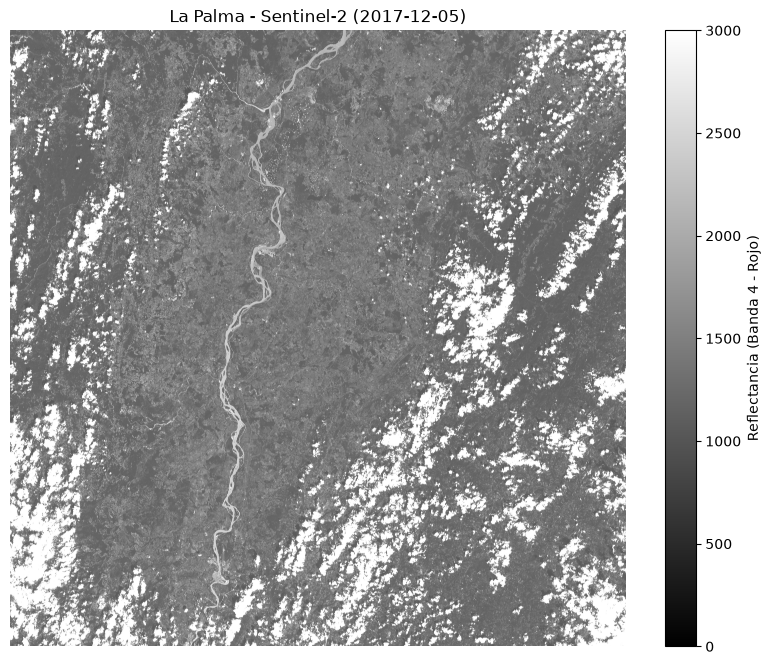

In [18]:
plt.figure(figsize=(10, 8))
plt.imshow(array_b04_2017, cmap="gray", vmin=0, vmax=3000)
plt.colorbar(label="Reflectancia (Banda 4 - Rojo)")
plt.title("La Palma - Sentinel-2 (2017-12-05)")
plt.axis("off")
plt.show()

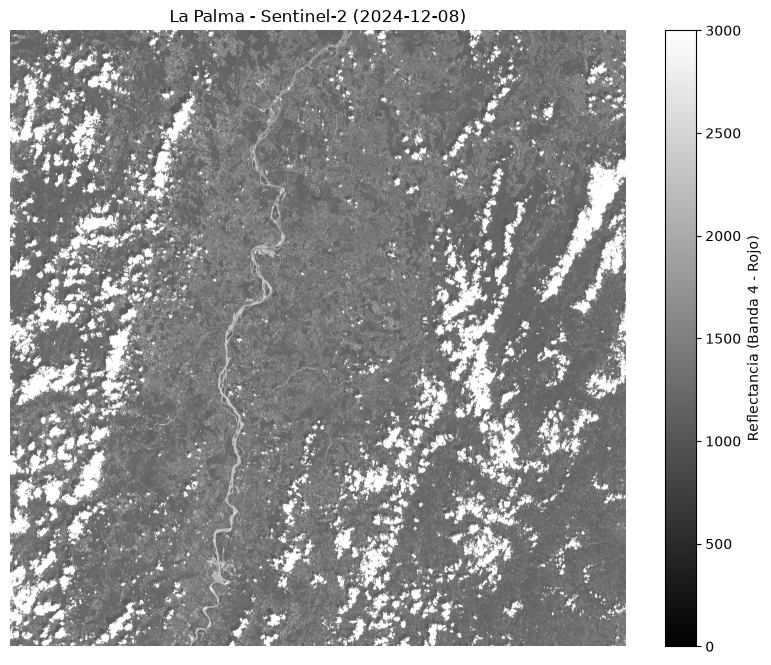

In [19]:
plt.figure(figsize=(10, 8))
plt.imshow(array_b04_2024, cmap="gray", vmin=0, vmax=3000)
plt.colorbar(label="Reflectancia (Banda 4 - Rojo)")
plt.title("La Palma - Sentinel-2 (2024-12-08)")
plt.axis("off")
plt.show()

#### 5.1.2. Creating a True-Colour (RGB) Composite 2017 and 2024

To construct a natural True-Colour satellite image, we combine three individual 10-metre spectral bands:
* **Red Channel:** Band 4 (`B04_10m.jp2`)
* **Green Channel:** Band 3 (`B03_10m.jp2`)
* **Blue Channel:** Band 2 (`B02_10m.jp2`)

Because Matplotlib expects an image array with dimensions `(Height, Width, Channels)` scaled between `0.0` and `1.0` (or `0` to `255`), we stack the arrays along the third axis using `numpy.dstack()` and normalise the surface reflectance values.

> 💡 **What is a `boto3.Session`?**
>
> Is an isolated configuration object that stores user authentication credentials (`AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`) and connection settings.
>
> Pairing `boto3.Session` with `rasterio`'s **`AWSSession`** passes these credentials directly to GDAL's virtual file system (`/vsis3/`). This authenticates remote S3 requests behind the scenes, allowing `rasterio` to stream cloud-native satellite imagery directly into memory without downloading files to local disk.

In [33]:
# 1. Define S3 path for Band 4 (Red) and construct paths for Band 3 (Green) and Band 2 (Blue) year 2017

# NEW: Use the selected 2017 Sentinel-2 product
product_key_2017 = "Sentinel-2/MSI/L2A_N0500/2017/12/05/S2B_MSIL2A_20171205T152629_N0500_R025_T18NWM_20230806T183241.SAFE"

# 2. Initialise the boto3 session and AWSSession for rasterio authentication
boto3_session_2017 = boto3.Session(
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"]
)

# Retrieve S3 storage endpoint from environment variables, defaulting to the Copernicus CDSE server URL if unassigned
endpoint_2017 = os.environ.get("AWS_S3_ENDPOINT", "eodata.dataspace.copernicus.eu")

# Sanitise the endpoint string by ensuring it includes the HTTPS protocol prefix required by GDAL and Boto3
if not endpoint_2017.startswith("http"):
    endpoint_2017 = f"https://{endpoint_2017}"
    
# Bind the authenticated boto3 credential session to the target endpoint to construct a Rasterio-compatible S3 session
rio_session_2017 = AWSSession(boto3_session_2017, endpoint_url=endpoint_2017)

# NEW: Find the GRANULE directory inside the selected SAFE product
s3_client_2017 = boto3_session_2017.client(
    "s3",
    endpoint_url=endpoint_2017
)

granule_response_2017 = s3_client_2017.list_objects_v2(
    Bucket="eodata",
    Prefix=product_key_2017 + "/GRANULE/",
    Delimiter="/"
)

granule_prefixes_2017 = [
    item["Prefix"]
    for item in granule_response_2017.get("CommonPrefixes", [])
]

if not granule_prefixes_2017:
    raise RuntimeError("No GRANULE directory was found for the selected 2017 product.")

granule_path_2017 = granule_prefixes_2017[0].rstrip("/")

# NEW: Define S3 path for Band 4 using the detected GRANULE
url_b04_2017 = (
    f"/vsis3/eodata/{granule_path_2017}/IMG_DATA/R10m/"
    "T18NWM_20171205T152629_B04_10m.jp2"
)

url_b03_2017 = url_b04_2017.replace("B04_10m.jp2", "B03_10m.jp2")  # Band 3 (Green)
url_b02_2017 = url_b04_2017.replace("B04_10m.jp2", "B02_10m.jp2")  # Band 2 (Blue)

# Helper function to open, read, and safely close each S3 raster dataset handle individually
def read_s3_band(url, session):
    """Safely reads a remote GDAL raster band into a NumPy array."""
    with rasterio.Env(session=session, AWS_VIRTUAL_HOSTING="FALSE"):
        with rasterio.open(url) as src:
            return src.read(1)

# 3. Read each spectral band into memory as NumPy arrays
print("Fetching Band 4 (Red) - 2017...")
red_2017 = read_s3_band(url_b04_2017, rio_session_2017)

print("Fetching Band 3 (Green) - 2017...")
green_2017 = read_s3_band(url_b03_2017, rio_session_2017)

print("Fetching Band 2 (Blue) - 2017...")
blue_2017 = read_s3_band(url_b02_2017, rio_session_2017)

# Let´s check the type of data of the variable "blue"
print(" type", blue_2017)

# 4. Stack individual 2D arrays into a 3D RGB array (Height, Width, Channels)
rgb_2017 = np.dstack((red_2017, green_2017, blue_2017))

# 5. Normalise surface reflectance values (scale 0-10000 range to 0.0-1.0 for visual rendering)
rgb_normalised_2017 = np.clip(rgb_2017 / 10000.0, 0, 1)

Fetching Band 4 (Red) - 2017...
Fetching Band 3 (Green) - 2017...
Fetching Band 2 (Blue) - 2017...
 type [[ 1228  1282  1474 ...  1490  1516  1494]
 [ 1338  1438  1501 ...  1594  1622  1605]
 [ 1444  1471  1442 ...  1786  1834  1791]
 ...
 [ 1322  1291  1286 ... 12424 12640 13040]
 [ 1309  1282  1302 ... 12256 12640 13384]
 [ 1327  1310  1296 ... 12144 12816 13688]]


In [34]:
# 1. Define S3 path for Band 4 (Red) and construct paths for Band 3 (Green) and Band 2 (Blue) year 2024

# NEW: Use the selected 2024 Sentinel-2 product
product_key_2024 = "Sentinel-2/MSI/L2A/2024/12/08/S2B_MSIL2A_20241208T152659_N0511_R025_T18NWM_20241208T201507.SAFE"

# 2. Initialise the boto3 session and AWSSession for rasterio authentication
boto3_session_2024 = boto3.Session(
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"]
)

# Retrieve S3 storage endpoint from environment variables, defaulting to the Copernicus CDSE server URL if unassigned
endpoint_2024 = os.environ.get("AWS_S3_ENDPOINT", "eodata.dataspace.copernicus.eu")

# Sanitise the endpoint string by ensuring it includes the HTTPS protocol prefix required by GDAL and Boto3
if not endpoint_2024.startswith("http"):
    endpoint_2024 = f"https://{endpoint_2024}"
    
# Bind the authenticated boto3 credential session to the target endpoint to construct a Rasterio-compatible S3 session
rio_session_2024 = AWSSession(boto3_session_2024, endpoint_url=endpoint_2024)

# NEW: Find the GRANULE directory inside the selected SAFE product
s3_client_2024 = boto3_session_2024.client(
    "s3",
    endpoint_url=endpoint_2024
)

granule_response_2024 = s3_client_2024.list_objects_v2(
    Bucket="eodata",
    Prefix=product_key_2024 + "/GRANULE/",
    Delimiter="/"
)

granule_prefixes_2024 = [
    item["Prefix"]
    for item in granule_response_2024.get("CommonPrefixes", [])
]

if not granule_prefixes_2024:
    raise RuntimeError("No GRANULE directory was found for the selected 2024 product.")

granule_path_2024 = granule_prefixes_2024[0].rstrip("/")

# NEW: Define S3 path for Band 4 using the detected GRANULE
url_b04_2024 = (
    f"/vsis3/eodata/{granule_path_2024}/IMG_DATA/R10m/"
    "T18NWM_20241208T152659_B04_10m.jp2"
)

url_b03_2024 = url_b04_2024.replace("B04_10m.jp2", "B03_10m.jp2")  # Band 3 (Green)
url_b02_2024 = url_b04_2024.replace("B04_10m.jp2", "B02_10m.jp2")  # Band 2 (Blue)

# Helper function to open, read, and safely close each S3 raster dataset handle individually
def read_s3_band_2024(url, session):
    """Safely reads a remote GDAL raster band into a NumPy array."""
    with rasterio.Env(session=session, AWS_VIRTUAL_HOSTING="FALSE"):
        with rasterio.open(url) as src:
            return src.read(1)

# 3. Read each spectral band into memory as NumPy arrays
print("Fetching Band 4 (Red) - 2024...")
red_2024 = read_s3_band_2024(url_b04_2024, rio_session_2024)

print("Fetching Band 3 (Green) - 2024...")
green_2024 = read_s3_band_2024(url_b03_2024, rio_session_2024)

print("Fetching Band 2 (Blue) - 2024...")
blue_2024 = read_s3_band_2024(url_b02_2024, rio_session_2024)

# Let´s check the type of data of the variable "blue"
print(" type", blue_2024)

# 4. Stack individual 2D arrays into a 3D RGB array (Height, Width, Channels)
rgb_2024 = np.dstack((red_2024, green_2024, blue_2024))

# 5. Normalise surface reflectance values (scale 0-10000 range to 0.0-1.0 for visual rendering)
rgb_normalised_2024 = np.clip(rgb_2024 / 10000.0, 0, 1)

Fetching Band 4 (Red) - 2024...
Fetching Band 3 (Green) - 2024...
Fetching Band 2 (Blue) - 2024...
 type [[1262 1406 1481 ... 1166 1166 1189]
 [1442 1476 1484 ... 1148 1179 1203]
 [1483 1415 1492 ... 1199 1240 1236]
 ...
 [1257 1287 1286 ... 1504 1478 1386]
 [1288 1302 1292 ... 1502 1468 1422]
 [1320 1301 1291 ... 1530 1510 1357]]


##### Mapping the RGB Composite
The code below renders a true-colour (RGB) composite of San Luis de Gaceno using Sentinel-2 optical bands (B04-Red, B03-Green, B02-Blue). 

To overcome the naturally low surface reflectance of dense tropical vegetation and produce an aesthetically balanced visual output, a non-linear enhancement and value-clamping pipeline is applied directly within the plot call:

* **Non-Linear Gamma Correction ($\gamma = 0.75$):** 
  Calculated using `np.power(rgb_normalised, 0.75)`, this power-law transformation non-linearly brightens shadow regions and mid-tones—such as dense rainforest canopy—without saturating high-reflectance features like cloud cover or bare soil:
  
  $$I_{\text{out}} = I_{\text{in}}^{\gamma}$$
  
  where $I_{\text{in}}$ and $I_{\text{out}}$ denote the normalized input and output pixel intensities, respectively.

* **Pixel Clamping (`np.clip(..., 0, 1)`):** 
  Enforces a strict numeric range of $[0.0, 1.0]$ required by Matplotlib for floating-point imagery, preventing visual artefacts or rendering warnings caused by out-of-bounds values.

* **Non-Destructive Rendering:** 
  Executing transformations dynamically inside `plt.imshow()` generates a temporary array purely for figure display, preserving the underlying `rgb_normalised` dataset in its original quantitative state for subsequent analytical tasks.

##### Mapping the RGB Composite 2017 and 2024

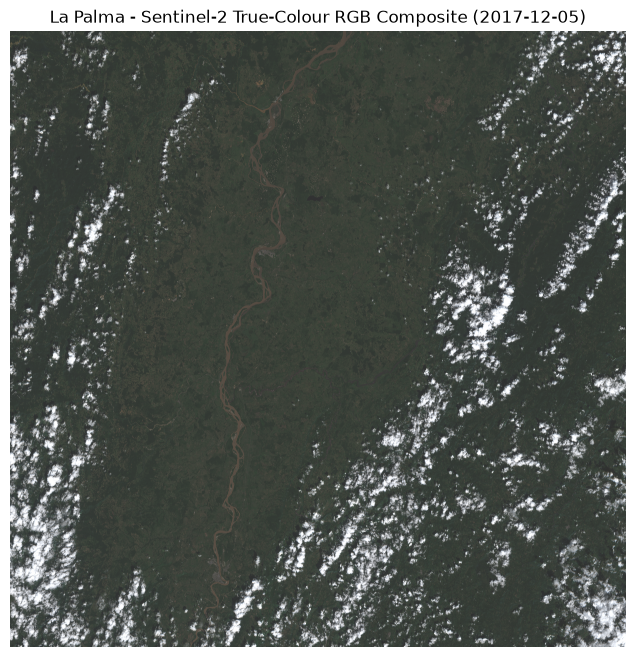

In [35]:
plt.figure(figsize=(10, 8))

# Apply a non-linear gamma correction (gamma = 0.75) directly within imshow to selectively brighten mid-tones
# (e.g. dense canopy cover) while clamping pixel values to [0.0, 1.0] for optimal, non-destructive visual rendering
plt.imshow(np.clip(np.power(rgb_normalised_2017, 0.75), 0, 1))
plt.title("La Palma - Sentinel-2 True-Colour RGB Composite (2017-12-05)")
plt.axis("off")
plt.show()

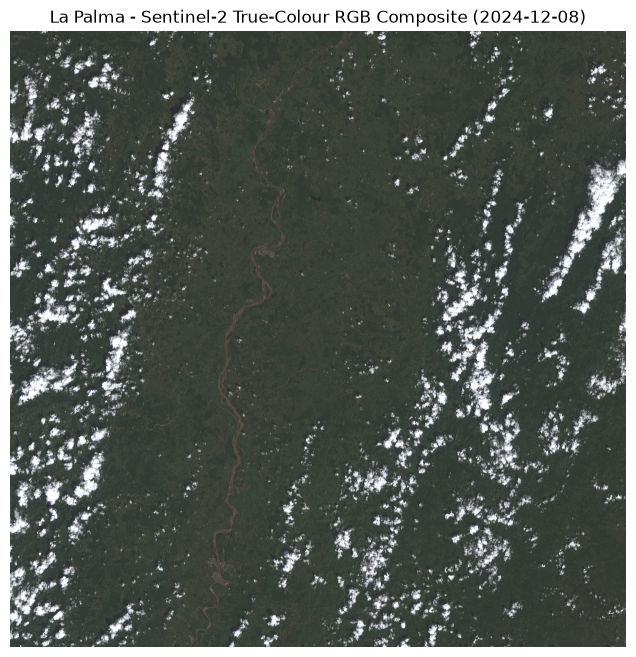

In [18]:
plt.figure(figsize=(10, 8))

# Apply a non-linear gamma correction (gamma = 0.75) directly within imshow to selectively brighten mid-tones
# (e.g. dense canopy cover) while clamping pixel values to [0.0, 1.0] for optimal, non-destructive visual rendering
plt.imshow(np.clip(np.power(rgb_normalised_2024, 0.75), 0, 1))
plt.title("La Palma - Sentinel-2 True-Colour RGB Composite (2024-12-08)")
plt.axis("off")
plt.show()

##  6. Zero-Disk In-Memory Web GIS Visualisation via Rioxarray, Leaflet, and MapLibre GL

While static image previews generated via Matplotlib provide a rapid mechanism for inspecting raster output, interactive Web GIS platforms require full cartographic context and dynamic tile-streaming capability. Up to this point, the spectral bands have been processed in memory as unreferenced numerical NumPy arrays, temporarily detached from real-world coordinates.

To overlay our enhanced True-Colour composite onto interactive web maps without exporting intermediate GeoTIFF files to disk, this section establishes a zero-disk spatial binding pipeline:

1. **Geospatial Header Extraction:** Retrieve the native Coordinate Reference System and 6-parameter Affine Transformation Matrix (`transform`) from the source dataset headers using `rasterio`.
2. **8-Bit Quantisation & Visual Parity:** Rescale the gamma-corrected floating-point reflectance values ($[0.0, 1.0]$) to an 8-bit unsigned integer byte range ($[0, 255]$, `np.uint8`), ensuring exact colour luminance parity between Matplotlib (`imshow`) and web tile rendering engines.
3. **In-Memory Metadata Binding (`rioxarray`):** Reorder array axes to geospatial layout $(\text{Bands}, Y, X)$ and bind the spatial reference parameters directly into an `xarray.DataArray` structure in RAM.
4. Stream the georeferenced array directly to interactive client canvases, evaluating two distinct architectural paradigms:
   * **Option A — Standard Leaflet (`ipyleaflet`):** CPU-bound 2D raster overlay with native Google Maps satellite integration.
   * **Option B — WebGL MapLibre (`maplibregl`):** GPU-accelerated 3D vector styling with dynamic camera controls and high-frame-rate pan/zoom performance.

**6.1. Extracting Geospatial Metadata (CRS & Affine Transform) years 2017 and 2024**

Although the spectral pixel values are already loaded in memory as NumPy arrays, they currently lack spatial reference parameters. To properly position and render this imagery on an interactive GIS canvas, we need to extract the original spatial header metadata from the remote dataset.

We open a temporary dataset handle on **Band 4** via `rasterio` to retrieve three fundamental spatial properties:

* **Affine Transformation Matrix (`src.transform`):** Defines the six-parameter mathematical relationship mapping array matrix indexes `(row, column)` to real-world ground coordinates `(X, Y)`. It includes the pixel pixel resolution ($10\text{ m} \times -10\text{ m}$) and the top-left spatial origin coordinates.
* **Coordinate Reference System (`src.crs`):** Specifies the projected coordinate system used by the scene (e.g. WGS 84 / UTM Zone 18N, EPSG:32618).
* **Bounding Extent (`src.bounds`):** Defines the spatial bounding envelope ($x_{\min}, y_{\min}, x_{\max}, y_{\max}$) covering the geographical coverage area of the scene.

#### Understanding the Affine Transformation Matrix in Georeferenced Rasters

In spatial data processing, a raw NumPy array is merely a two- or three-dimensional grid of numerical values without any geographic context. The **Affine Transformation Matrix** provides the mathematical mapping that links matrix pixel coordinates (row, column indices) to real-world spatial coordinates (e.g. UTM Eastings and Northings in metres, or WGS84 Geographic Longitude and Latitude).

For any pixel located at column index $\text{col}$ and row index $\text{row}$, the corresponding geographic coordinate $(X, Y)$ is computed using the $3 \times 3$ affine transformation matrix:

$$\begin{bmatrix} X \\ Y \\ 1 \end{bmatrix} =  \begin{bmatrix}  a & b & c \\  d & e & f \\  0 & 0 & 1  \end{bmatrix}  \begin{bmatrix} \text{col} \\ \text{row} \\ 1 \end{bmatrix}$$

In Python libraries such as `rasterio` and GDAL, this matrix is represented as `Affine(a, b, c, d, e, f)`.

---

#### Matrix Elements and Spatial Representation

| Parameter | Coefficient Name | Primary Geographic Function | Sentinel-2 Example (10m) |
| :--- | :--- | :--- | :--- |
| **`a`** | $x$-scale / Pixel Width | Horizontal resolution (spatial width of a pixel along the $X$-axis). | $+10.0\text{ m}$ |
| **`b`** | $x$-shear / Row Rotation | Rotation factor along rows (usually $0.0$ for standard north-up rasters). | $0.0$ |
| **`c`** | $x$-origin / Easting ($X_0$) | The absolute $X$-coordinate of the top-left corner of the top-left pixel. | $600000.0\text{ m}$ |
| **`d`** | $y$-shear / Column Rotation | Rotation factor along columns (usually $0.0$ for standard north-up rasters). | $0.0$ |
| **`e`** | $y$-scale / Pixel Height | Vertical resolution along the $Y$-axis. **Always negative** for north-up rasters. | $-10.0\text{ m}$ |
| **`f`** | $y$-origin / Northing ($Y_0$) | The absolute $Y$-coordinate of the top-left corner of the top-left pixel. | $5000000.0\text{ m}$ |

---

Extracting `src.transform` directly from the remote S3 header captures parameters $a$ through $f$. Combining this matrix with the Coordinate Reference System (CRS) allows interactive viewers like `leafmap` to place raw arrays accurately onto interactive map canvases without altering pixel values.

In [41]:
# Extract the affine transformation matrix and Coordinate Reference System (CRS)
affine_transform_2017 = rasterio.Affine(10.0, 0.0, 499980.0, 0.0, -10.0, 700020.0)
crs_2017 = "EPSG:32618"
bounds_2017 = rasterio.coords.BoundingBox(
    left=499980.0,
    bottom=590220.0,
    right=609780.0,
    top=700020.0
)

print("Affine Transform 2017:", affine_transform_2017)
print("CRS 2017:", crs_2017)
print("Bounds 2017:", bounds_2017)

# NEW: Normalize the RGB composite for 2017
rgb_normalised_2017 = np.clip(rgb_2017 / 10000.0, 0, 1)

Affine Transform 2017: | 10.00, 0.00, 499980.00|
| 0.00,-10.00, 700020.00|
| 0.00, 0.00, 1.00|
CRS 2017: EPSG:32618
Bounds 2017: BoundingBox(left=499980.0, bottom=590220.0, right=609780.0, top=700020.0)


In [42]:
rgb_normalised_2017

array([[[0.127 , 0.1387, 0.1228],
        [0.1359, 0.1539, 0.1282],
        [0.1539, 0.1854, 0.1474],
        ...,
        [0.1337, 0.1498, 0.149 ],
        [0.1331, 0.1512, 0.1516],
        [0.137 , 0.1528, 0.1494]],

       [[0.1386, 0.1634, 0.1338],
        [0.15  , 0.1848, 0.1438],
        [0.1538, 0.1936, 0.1501],
        ...,
        [0.1438, 0.1588, 0.1594],
        [0.1429, 0.1612, 0.1622],
        [0.1414, 0.1602, 0.1605]],

       [[0.1526, 0.1893, 0.1444],
        [0.1512, 0.1929, 0.1471],
        [0.1473, 0.1865, 0.1442],
        ...,
        [0.1568, 0.1758, 0.1786],
        [0.1572, 0.1768, 0.1834],
        [0.1558, 0.1766, 0.1791]],

       ...,

       [[0.1243, 0.156 , 0.1322],
        [0.1236, 0.1538, 0.1291],
        [0.1232, 0.157 , 0.1286],
        ...,
        [1.    , 1.    , 1.    ],
        [1.    , 1.    , 1.    ],
        [1.    , 1.    , 1.    ]],

       [[0.1275, 0.1618, 0.1309],
        [0.1256, 0.157 , 0.1282],
        [0.1229, 0.1524, 0.1302],
        .

In [43]:
# Extract the affine transformation matrix and Coordinate Reference System (CRS)
affine_transform_2024 = rasterio.Affine(10.0, 0.0, 499980.0, 0.0, -10.0, 700020.0)
crs_2024 = "EPSG:32618"
bounds_2024 = rasterio.coords.BoundingBox(
    left=499980.0,
    bottom=590220.0,
    right=609780.0,
    top=700020.0
)

print("Affine Transform 2024:", affine_transform_2024)
print("CRS 2024:", crs_2024)
print("Bounds 2024:", bounds_2024)

# NEW: Normalize the RGB composite for 2024
rgb_normalised_2024 = np.clip(rgb_2024 / 10000.0, 0, 1)

Affine Transform 2024: | 10.00, 0.00, 499980.00|
| 0.00,-10.00, 700020.00|
| 0.00, 0.00, 1.00|
CRS 2024: EPSG:32618
Bounds 2024: BoundingBox(left=499980.0, bottom=590220.0, right=609780.0, top=700020.0)


In [44]:
rgb_normalised_2024

array([[[0.1301, 0.1524, 0.1262],
        [0.1475, 0.1756, 0.1406],
        [0.1582, 0.1866, 0.1481],
        ...,
        [0.1138, 0.1276, 0.1166],
        [0.116 , 0.1345, 0.1166],
        [0.1161, 0.1372, 0.1189]],

       [[0.1484, 0.1825, 0.1442],
        [0.1564, 0.1882, 0.1476],
        [0.1572, 0.1877, 0.1484],
        ...,
        [0.1139, 0.1275, 0.1148],
        [0.1166, 0.1333, 0.1179],
        [0.1167, 0.1405, 0.1203]],

       [[0.1494, 0.187 , 0.1483],
        [0.147 , 0.1802, 0.1415],
        [0.15  , 0.1836, 0.1492],
        ...,
        [0.1176, 0.1407, 0.1199],
        [0.1212, 0.147 , 0.124 ],
        [0.1216, 0.145 , 0.1236]],

       ...,

       [[0.1211, 0.1464, 0.1257],
        [0.121 , 0.145 , 0.1287],
        [0.1208, 0.1464, 0.1286],
        ...,
        [0.1639, 0.1845, 0.1504],
        [0.1573, 0.1792, 0.1478],
        [0.1466, 0.1637, 0.1386]],

       [[0.1231, 0.1522, 0.1288],
        [0.1237, 0.1506, 0.1302],
        [0.1223, 0.149 , 0.1292],
        .

**6.2. In-Memory Processing and Spatial Metadata Binding years 2017 and 2024**

To ensure optimal visual brightness and performance, the processing workflow performs three in-memory transformations before passing the array to any Web GIS backend:

1. **Non-Linear Gamma Correction ($\gamma = 0.75$):** Lifts mid-tone reflectance across canopy cover.
2. **8-Bit Dynamic Range Casting:** Scales floating-point values ($0.0\text{--}1.0$) to an 8-bit unsigned integer range ($0\text{--}255$, `np.uint8`). This delivers exact colour and brightness parity between Matplotlib (`imshow`) and Web GIS tile servers.
3. **Spatial Metadata Binding:** Reorders array axes from visual $(Y, X, \text{Band})$ to geospatial $(\text{Band}, Y, X)$ and attaches the CRS and 6-parameter affine transformation matrix using `rioxarray`.

In [ ]:
import numpy as np
import rioxarray
import xarray as xr

# 1. Apply non-linear gamma correction (gamma = 0.75) to lift mid-tone reflectance across canopy cover
rgb_enhanced_2017 = np.clip(np.power(rgb_normalised_2017, 0.75), 0, 1)

# 2. Scale float array [0.0, 1.0] to 8-bit integer range [0, 255] and cast to uint8
# This ensures exact colour luminance parity between Matplotlib imshow() and Leafmap web tile engines
rgb_uint8_2017 = (rgb_enhanced_2017 * 255).astype(np.uint8)

# 3. Transpose array from visual (Y, X, Band) to geospatial (Band, Y, X) ordering
# and construct an xarray.DataArray with explicit dimension labels required by rioxarray
da_2017 = xr.DataArray(
    rgb_uint8_2017.transpose(2, 0, 1),
    dims=["band", "y", "x"],
)

# 4. Attach spatial reference metadata (CRS and Affine transformation matrix) to the DataArray
da_2017 = da_2017.rio.write_crs(crs_2017)
da_2017 = da_2017.rio.write_transform(affine_transform_2017)

In [25]:
import numpy as np
import rioxarray
import xarray as xr

# 1. Apply non-linear gamma correction (gamma = 0.75) to lift mid-tone reflectance across canopy cover
rgb_enhanced_2024 = np.clip(np.power(rgb_normalised_2024, 0.75), 0, 1)

# 2. Scale float array [0.0, 1.0] to 8-bit integer range [0, 255] and cast to uint8
# This ensures exact colour luminance parity between Matplotlib imshow() and Leafmap web tile engines
rgb_uint8_2024 = (rgb_enhanced_2024 * 255).astype(np.uint8)

# 3. Transpose array from visual (Y, X, Band) to geospatial (Band, Y, X) ordering
# and construct an xarray.DataArray with explicit dimension labels required by rioxarray
da_2024 = xr.DataArray(
    rgb_uint8_2024.transpose(2, 0, 1),
    dims=["band", "y", "x"],
)

# 4. Attach spatial reference metadata (CRS and Affine transformation matrix) to the DataArray
da_2024 = da_2024.rio.write_crs(crs_2024)
da_2024 = da_2024.rio.write_transform(affine_transform_2024)

**Option A: 2D Visualisation via Standard Leaflet (ipyleaflet)**

This approach uses the standard Leaflet 2D rendering engine. It is ideal when native Google Maps tile integration (`google_map="HYBRID"`) is required or when working in environments without GPU acceleration.

* **Coordinate Syntax:** Uses standard geographical ordering **`[Latitude, Longitude]`** (`[4.82, -73.17]`).
* **Basemap Engine:** Loads raster basemaps directly via tile providers.

In [ ]:
import leafmap.maplibregl as leafmap

# Renderizar usando el estilo libre 'liberty' (sin necesidad de API Key)
m_maplibre_2017 = leafmap.Map(center=[-74.390, 5.358], zoom=12, style="liberty")
m_maplibre_2017.add_raster(
    da_2017, bands=[1, 2, 3], layer_name="Sentinel-2 True-Colour 2017 (MapLibre WebGL)"
)
m_maplibre_2017

In [69]:
import leafmap.maplibregl as leafmap

# Renderizar usando el estilo libre 'liberty' (sin necesidad de API Key)
m_maplibre_2024 = leafmap.Map(center=[-74.390, 5.358], zoom=12, style="liberty")
m_maplibre_2024.add_raster(
    da_2024, bands=[1, 2, 3], layer_name="Sentinel-2 True-Colour 2024 (MapLibre WebGL)"
)
m_maplibre_2024

Html(children=[<leafmap.maplibregl.Map object at 0x000000472935E690>, Card(children=[Btn(children=[Icon(childr…

### 7. Cloud-Native Spatial Subsetting, Local GeoTIFF Export, and Verification 2017 and 2024 images

This section details the end-to-end workflow for extracting a targeted spatial subset directly from Sentinel-2 L2A granules hosted on Copernicus AWS S3 storage, assembling a multi-band True-Colour composite, and exporting a fully georeferenced local GeoTIFF.

By executing server-side cropping on remote JP2 assets via GDAL's virtual file system (`/vsis3/`), this pipeline bypasses the need to download gigabyte-scale full scenes, drastically reducing memory overhead and network latency.

**7.1. Cloud-Native Spatial Subsetting and Multi-Band Array Assembly**

This step performs server-side spatial subsetting directly against remote Copernicus S3 assets without downloading full-scene granules. By leveraging GDAL's virtual file system (`/vsis3/`) alongside `rasterio.mask`, pixel data within a target Area of Interest (AOI) bounding box are selectively streamed over the network.


1. Configures an authenticated `AWSSession` via `boto3` to connect to the Copernicus Data Space Ecosystem S3 endpoint.
2. Constructs a geographic bounding box in WGS 84 coordinates (`EPSG:4326`) around San Luis de Gaceno using `shapely` and `geopandas`.
3. Reprojects the vector geometry to match the scene's native UTM projection (`EPSG:32618`) and clips each spectral band on the fly inside an isolated `rasterio.Env` context manager.
4. Combines individual clipped 2D spectral arrays (Red, Green, Blue) into a unified 3D array $(\text{Bands}, Y, X)$.
5. Updates the geospatial metadata profile (`GTiff` driver, clipped dimensions, affine transform, CRS, and `nodata` mask) in preparation for raster writing.

In [27]:
# 1. Define S3 paths for Bands 4 (Red), 3 (Green), and 2 (Blue)
import rasterio
from rasterio.mask import mask
from rasterio.session import AWSSession
import geopandas as gpd
from shapely.geometry import box


# 1. Define S3 paths for Bands 4 (Red), 3 (Green), and 2 (Blue)
url_b04_2017 = "/vsis3/eodata/Sentinel-2/MSI/L2A_N0500/2017/12/05/S2B_MSIL2A_20171205T152629_N0500_R025_T18NWM_20230806T183241.SAFE/GRANULE/L2A_T18NWM_A003912_20171205T152627/IMG_DATA/R10m/T18NWM_20171205T152629_B04_10m.jp2"
url_b03_2017 = url_b04_2017.replace("B04_10m.jp2", "B03_10m.jp2")
url_b02_2017 = url_b04_2017.replace("B04_10m.jp2", "B02_10m.jp2")


# 2. Initialise the boto3 session and AWSSession for S3 authentication
boto3_session = boto3.Session(
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"]
)

endpoint = os.environ.get("AWS_S3_ENDPOINT", "eodata.dataspace.copernicus.eu")

if not endpoint.startswith("http"):
    endpoint = f"https://{endpoint}"

rio_session = AWSSession(boto3_session, endpoint_url=endpoint)


# 3. Create a sample Area of Interest (AOI) near La Palma
min_lon, min_lat = -74.410, 5.338
max_lon, max_lat = -74.370, 5.378

aoi_polygon = box(min_lon, min_lat, max_lon, max_lat)
gdf_aoi = gpd.GeoDataFrame(
    {"geometry": [aoi_polygon]},
    crs="EPSG:4326"
)


# Helper function to safely open, clip, and return array data
def clip_s3_band(url, session, gdf_aoi):
    """Safely opens an S3 raster dataset, reprojects AOI geometry, clips the raster, and closes handles."""
    with rasterio.Env(session=session, AWS_VIRTUAL_HOSTING="FALSE"):
        with rasterio.open(url) as src:
            # Reproject AOI geometry to match the dataset's native CRS
            gdf_utm = gdf_aoi.to_crs(src.crs)
            shapes = [geom for geom in gdf_utm.geometry]
            
            # Clip raster using spatial mask
            clipped_data, transform = mask(
                src,
                shapes,
                crop=True
            )
            
            meta = src.meta.copy()
            
            return clipped_data, transform, meta


# 4. Read and clip each spectral band
print("Clipping Band 4 (Red) - 2017...")
clipped_r_2017, out_transform_2017, out_meta_2017 = clip_s3_band(
    url_b04_2017,
    rio_session,
    gdf_aoi
)

print("Clipping Band 3 (Green) - 2017...")
clipped_g_2017, _, _ = clip_s3_band(
    url_b03_2017,
    rio_session,
    gdf_aoi
)

print("Clipping Band 2 (Blue) - 2017...")
clipped_b_2017, _, _ = clip_s3_band(
    url_b02_2017,
    rio_session,
    gdf_aoi
)


# 5. Stack clipped 2D arrays into a 3D multi-band array
clipped_rgb_2017 = np.vstack([
    clipped_r_2017,
    clipped_g_2017,
    clipped_b_2017
])


# 6. Update metadata profile for multi-band GeoTIFF output
out_meta_2017.update({
    "driver": "GTiff",
    "height": clipped_rgb_2017.shape[1],
    "width": clipped_rgb_2017.shape[2],
    "transform": out_transform_2017,
    "count": 3,
    "nodata": 0
})

Clipping Band 4 (Red) - 2017...
Clipping Band 3 (Green) - 2017...
Clipping Band 2 (Blue) - 2017...


In [28]:
url_b04_2024 = "/vsis3/eodata/Sentinel-2/MSI/L2A/2024/12/08/S2B_MSIL2A_20241208T152659_N0511_R025_T18NWM_20241208T201507.SAFE/GRANULE/L2A_T18NWM_A040520_20241208T152653/IMG_DATA/R10m/T18NWM_20241208T152659_B04_10m.jp2"
url_b03_2024 = url_b04_2024.replace("B04_10m.jp2", "B03_10m.jp2")
url_b02_2024 = url_b04_2024.replace("B04_10m.jp2", "B02_10m.jp2")

print("Clipping Band 4 (Red) - 2024...")
clipped_r_2024, out_transform_2024, out_meta_2024 = clip_s3_band(
    url_b04_2024, rio_session, gdf_aoi
)

print("Clipping Band 3 (Green) - 2024...")
clipped_g_2024, _, _ = clip_s3_band(
    url_b03_2024, rio_session, gdf_aoi
)

print("Clipping Band 2 (Blue) - 2024...")
clipped_b_2024, _, _ = clip_s3_band(
    url_b02_2024, rio_session, gdf_aoi
)

clipped_rgb_2024 = np.vstack([
    clipped_r_2024,
    clipped_g_2024,
    clipped_b_2024
])

out_meta_2024.update({
    "driver": "GTiff",
    "height": clipped_rgb_2024.shape[1],
    "width": clipped_rgb_2024.shape[2],
    "transform": out_transform_2024,
    "count": 3,
    "nodata": 0
})

print("2024 clipping completed.")
print("Clipped RGB shape:", clipped_rgb_2024.shape)

Clipping Band 4 (Red) - 2024...
Clipping Band 3 (Green) - 2024...
Clipping Band 2 (Blue) - 2024...
2024 clipping completed.
Clipped RGB shape: (3, 427, 445)


**7.2 Multi-Band GeoTIFF Export, Metadata Tagging, and Visual Verification from 2017 and 2024**

Complete the cloud-native spatial subsetting workflow by exporting the clipped 3D spectral array to a local multi-band GeoTIFF file, embedding custom metadata tags, and validating the exported file structure.

1.  Exports the stacked array (`clipped_rgb`) to disk using the updated spatial metadata profile (`out_meta`), preserving spatial extent and CRS alignment.
2.  Injects explicit band labels (`B04 - Red`, `B03 - Green`, `B02 - Blue`) into the GeoTIFF header using `set_band_description()` to ensure dataset provenance and GIS interoperability.
3.  Reopens the generated file to verify dataset integrity, confirming total band count and custom channel descriptions.
4.  Reads the exported raster, transposes array axes from $(\text{Channels}, Y, X)$ to visual $(Y, X, \text{Channels})$ ordering using `np.moveaxis()`, and rescales surface reflectance for Matplotlib rendering.

In [ ]:
# Write multi-band GeoTIFF and assign custom band descriptions
output_geotiff_2017 = "la_palma_rgb_2017_clipped.tif"

with rasterio.open(output_geotiff_2017, "w", **out_meta_2017) as dst:
    dst.write(clipped_rgb_2017)
    
    # Assign specific spectral band names to dataset metadata
    dst.set_band_description(1, "B04 - Red (10m)")
    dst.set_band_description(2, "B03 - Green (10m)")
    dst.set_band_description(3, "B02 - Blue (10m)")

print(f"✅ Clipped GeoTIFF successfully exported to: {output_geotiff_2017}")

# 8. Verify saved file metadata and display the clipped True-Colour composite
with rasterio.open(output_geotiff_2017) as verification_src:
    print("\n--- Exported GeoTIFF Metadata Verification ---")
    print("Band count:", verification_src.count)
    print("Custom band names:", verification_src.descriptions)
    
    # Read stacked bands for visualisation
    rgb_data = verification_src.read()
    
    # Rearrange array shape from (Channels, Height, Width) to (Height, Width, Channels) for Matplotlib
    rgb_display = np.moveaxis(rgb_data, 0, -1)
    rgb_normalised = np.clip(rgb_display / 3000.0, 0, 1)

In [80]:
# Write multi-band GeoTIFF and assign custom band descriptions
output_geotiff_2024 = "la_palma_rgb_2024_clipped.tif"

with rasterio.open(output_geotiff_2024, "w", **out_meta_2024) as dst:
    dst.write(clipped_rgb_2024)
    
    # Assign specific spectral band names to dataset metadata
    dst.set_band_description(1, "B04 - Red (10m)")
    dst.set_band_description(2, "B03 - Green (10m)")
    dst.set_band_description(3, "B02 - Blue (10m)")

print(f"✅ Clipped GeoTIFF successfully exported to: {output_geotiff_2024}")

# 8. Verify saved file metadata and display the clipped True-Colour composite
with rasterio.open(output_geotiff_2024) as verification_src:
    print("\n--- Exported GeoTIFF Metadata Verification ---")
    print("Band count:", verification_src.count)
    print("Custom band names:", verification_src.descriptions)
    
    # Read stacked bands for visualisation
    rgb_data = verification_src.read()
    
    # Rearrange array shape from (Channels, Height, Width) to (Height, Width, Channels) for Matplotlib
    rgb_display = np.moveaxis(rgb_data, 0, -1)
    rgb_normalised = np.clip(rgb_display / 3000.0, 0, 1)

✅ Clipped GeoTIFF successfully exported to: la_palma_rgb_2024_clipped.tif

--- Exported GeoTIFF Metadata Verification ---
Band count: 3
Custom band names: ('B04 - Red (10m)', 'B03 - Green (10m)', 'B02 - Blue (10m)')


**7.3. True-Colour Visualisation of the Clipped Raster**

This final step displays the cropped multi-band raster composite to confirm spatial extent accuracy and visual quality before proceeding to interactive GIS rendering.

* **Canvas Setup:** Configures a square $8 \times 8$ inch figure canvas for optimal display resolution.
* **Array Rendering:** Uses `plt.imshow()` to render the normalised RGB reflectance array ($[0.0, 1.0]$ floating-point range).
* **Cartographic Formatting:** Suppresses tick marks and axis borders (`plt.axis("off")`) to produce a clean map preview of the San Luis de Gaceno region.

In [ ]:
# Render the clipped RGB image - 2017
plt.figure(figsize=(8, 8))
plt.imshow(rgb_normalised_2017)
plt.title("Clipped RGB GeoTIFF - La Palma 2017")
plt.axis("off")
plt.show()

In [ ]:
# Render the clipped RGB image - 2024
plt.figure(figsize=(8, 8))
plt.imshow(rgb_normalised_2024)
plt.title("Clipped RGB GeoTIFF - La Palma 2024")
plt.axis("off")
plt.show()

**7.1.3. Verify saved GeoTIFFS**

In [9]:
import rasterio
import numpy as np

file_2017 = "la_palma_rgb_2017_clipped.tif"
file_2024 = "la_palma_rgb_2024_clipped.tif"

with rasterio.open(file_2017) as src_2017:
    rgb_2017 = src_2017.read()
    profile_2017 = src_2017.profile

with rasterio.open(file_2024) as src_2024:
    rgb_2024 = src_2024.read()
    profile_2024 = src_2024.profile

print("2017 shape:", rgb_2017.shape)
print("2024 shape:", rgb_2024.shape)
print("2017 CRS:", profile_2017["crs"])
print("2024 CRS:", profile_2024["crs"])

2017 shape: (3, 427, 445)
2024 shape: (3, 427, 445)
2017 CRS: EPSG:32618
2024 CRS: EPSG:32618


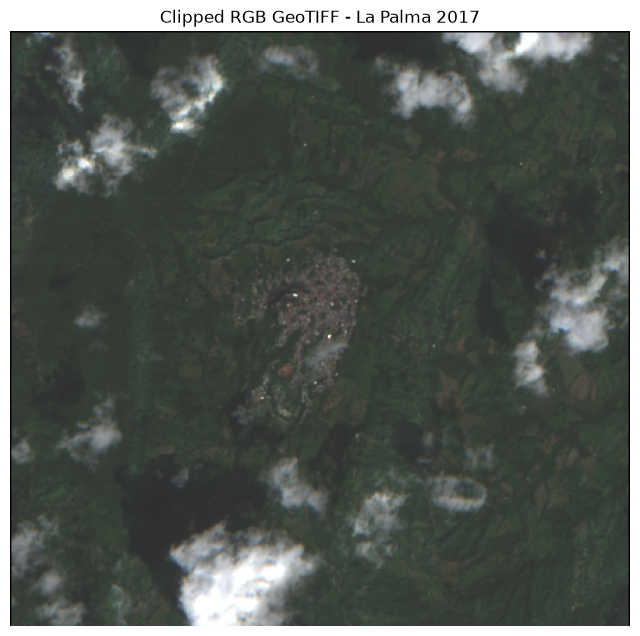

In [39]:
# Read the saved 2017 GeoTIFF and prepare RGB for visualisation
with rasterio.open("la_palma_rgb_2017_clipped.tif") as src:
    rgb_data = src.read()

# Rearrange array shape from (Channels, Height, Width) to (Height, Width, Channels)
rgb_display = np.moveaxis(rgb_data, 0, -1)

# Apply the same visual enhancement used in the initial RGB image
rgb_normalised_2017 = np.clip(rgb_display / 10000.0, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(np.clip(np.power(rgb_normalised_2017, 0.75), 0, 1))
plt.title("Clipped RGB GeoTIFF - La Palma 2017")
plt.axis("off")
plt.show()

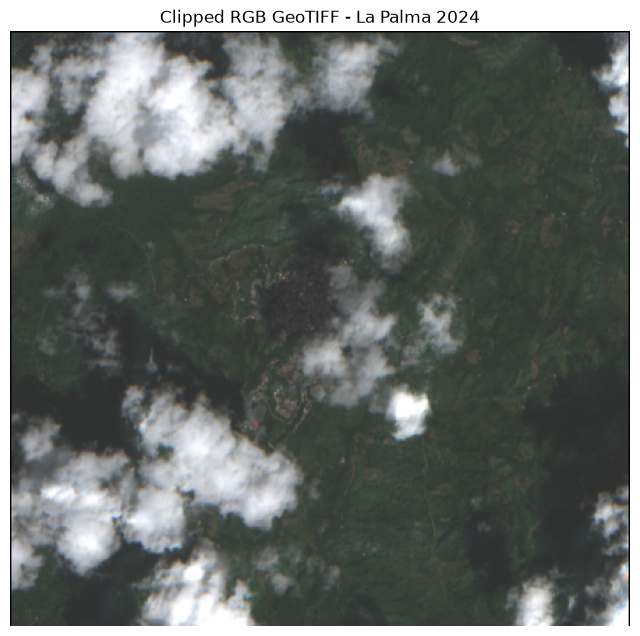

In [40]:
# Read the saved 2024 GeoTIFF and prepare RGB for visualisation
with rasterio.open("la_palma_rgb_2024_clipped.tif") as src:
    rgb_data = src.read()

# Rearrange array shape from (Channels, Height, Width) to (Height, Width, Channels)
rgb_display = np.moveaxis(rgb_data, 0, -1)

# Apply the same visual enhancement used in the initial RGB image
rgb_normalised_2024 = np.clip(rgb_display / 10000.0, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(np.clip(np.power(rgb_normalised_2024, 0.75), 0, 1))
plt.title("Clipped RGB GeoTIFF - La Palma 2024")
plt.axis("off")
plt.show()

**7.4. Comparison panel using leafmap**

In [ ]:
# =============================================================================
# 7.3 — Difference between 2017 and 2024
# =============================================================================

with rasterio.open(file_2017) as src_2017:
    rgb_2017 = src_2017.read()
    profile_2017 = src_2017.profile

with rasterio.open(file_2024) as src_2024:
    rgb_2024 = src_2024.read()
    profile_2024 = src_2024.profile

# Calculate B04 difference: 2024 minus 2017
difference_b04 = (
    rgb_2024[0].astype(np.int32) -
    rgb_2017[0].astype(np.int32)
)

output_difference = "la_palma_difference_B04_2017_2024.tif"

difference_profile = profile_2024.copy()
difference_profile.update({
    "driver": "GTiff",
    "height": difference_b04.shape[0],
    "width": difference_b04.shape[1],
    "count": 1,
    "dtype": "int32",
    "nodata": None
})

with rasterio.open(output_difference, "w", **difference_profile) as dst:
    dst.write(difference_b04, 1)
    dst.set_band_description(1, "B04 Difference (2024 - 2017)")

print(f"✅ Difference GeoTIFF successfully exported to: {output_difference}")

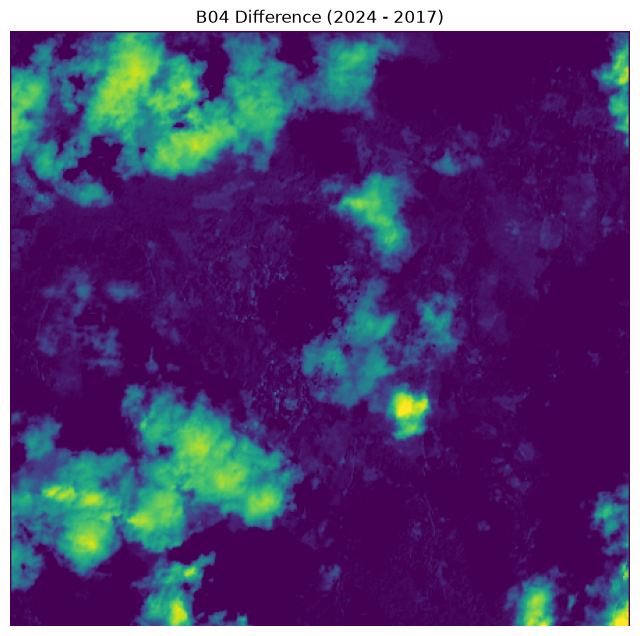

In [41]:
# Read the saved 2024 GeoTIFF and prepare RGB for visualisation
with rasterio.open("la_palma_difference_B04_2017_2024.tif") as src:
    rgb_data = src.read()

# Rearrange array shape from (Channels, Height, Width) to (Height, Width, Channels)
rgb_display = np.moveaxis(rgb_data, 0, -1)

# Apply the same visual enhancement used in the initial RGB image
rgb_normalised_2024 = np.clip(rgb_display / 10000.0, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(np.clip(np.power(rgb_normalised_2024, 0.75), 0, 1))
plt.title("B04 Difference (2024 - 2017)")
plt.axis("off")
plt.show()

In [3]:
import os

os.environ["LOCALTILESERVER_DISABLE_JUPYTER_LOOPBACK"] = "1"

In [4]:
file_2017 = "la_palma_rgb_2017_clipped.tif"
file_2024 = "la_palma_rgb_2024_clipped.tif"
file_B04 = "la_palma_difference_B04_2017_2024.tif"

In [5]:
import leafmap

file_2017 = "la_palma_rgb_2017_clipped.tif"
file_2024 = "la_palma_rgb_2024_clipped.tif"
file_B04 = "la_palma_difference_B04_2017_2024.tif"

m = leafmap.Map(
    center=[5.358, -74.390],
    zoom=12,
    google_map="HYBRID"
)

m.add_raster(
    file_2017,
    bands=[1, 2, 3],
    vmin=0,
    vmax=3000,
    layer_name="La Palma — 2017"
)

m.add_raster(
    file_2024,
    bands=[1, 2, 3],
    vmin=0,
    vmax=3000,
    layer_name="La Palma — 2024"
)

m.add_raster(
    file_B04,
    colormap="RdYlGn",
    vmin=-1000,
    vmax=1000,
    layer_name="B04 Difference — 2024 minus 2017"
)

m.add_layer_control()
m

Map(center=[5.3587605, -74.389993], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

In [9]:
import leafmap

file_2017 = "la_palma_rgb_2017_clipped.tif"
file_2024 = "la_palma_rgb_2024_clipped.tif"
file_B04 = "la_palma_difference_B04_2017_2024.tif"

m = leafmap.Map(
    center=[5.358, -74.390],
    zoom=12,
    google_map="HYBRID"
)

m.add_raster(
    file_2017,
    bands=[1, 2, 3],
    vmin=0,
    vmax=3000,
    layer_name="La Palma — 2017"
)

m.add_raster(
    file_2024,
    bands=[1, 2, 3],
    vmin=0,
    vmax=3000,
    layer_name="La Palma — 2024"
)

m.add_raster(
    file_B04,
    colormap="RdYlGn",
    vmin=-1000,
    vmax=1000,
    layer_name="B04 Difference — 2024 minus 2017"
)

m.add_layer_control()
m

## Show the Legend

from ipyleaflet import WidgetControl
import ipywidgets as widgets

legend = widgets.HTML(
    value="""
    <div style="
        background-color: white;
        padding: 10px 14px;
        border: 1px solid #777;
        border-radius: 5px;
        box-shadow: 0 1px 4px rgba(0,0,0,0.3);
        font-size: 13px;
        line-height: 1.5;
        width: 250px;
    ">
        <div style="font-weight: bold; font-size: 14px; margin-bottom: 6px;">
            La Palma — Análisis multitemporal
        </div>

        <b>Municipio:</b> La Palma, Cundinamarca<br>
        <b>Periodo:</b> 2017–2024<br>
        <b>Resolución:</b> 10 m

        <hr style="margin: 7px 0;">

        🛰️ <b>RGB Sentinel-2</b> — 2017<br>
        🛰️ <b>RGB Sentinel-2</b> — 2024<br>
        📊 <b>Diferencia B04</b> — 2024 − 2017
    </div>
    """
)

legend_control = WidgetControl(
    widget=legend,
    position="bottomleft"
)

m.add_control(legend_control)

m

Map(center=[5.3587605, -74.389993], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

## 8. Difference image — Histogram and descriptive statistics

Difference image statistics:
Mean: 784.61
Min: -14332.00
Max: 13960.00
Standard deviation: 2338.85


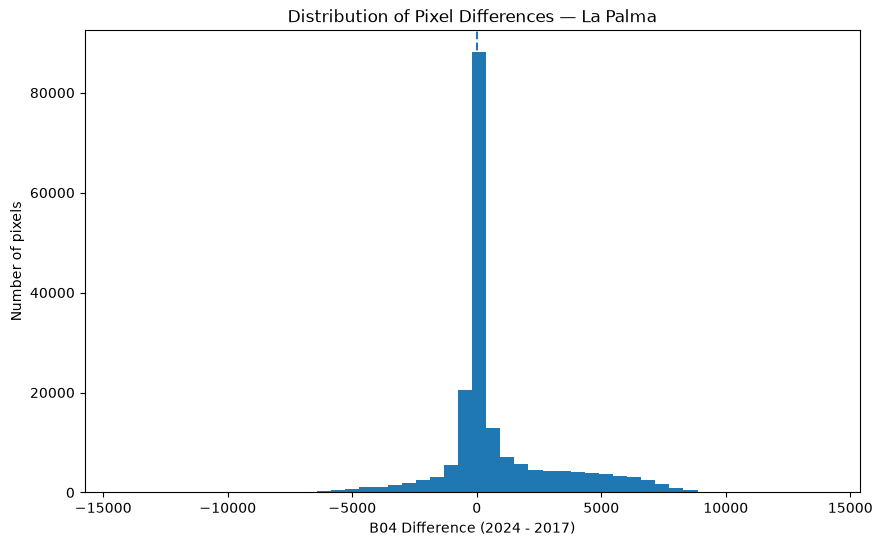

In [44]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

file_B04 = "la_palma_difference_B04_2017_2024.tif"

with rasterio.open(file_B04) as src:
    difference = src.read(1)

# Basic descriptive statistics
print("Difference image statistics:")
print(f"Mean: {np.mean(difference):.2f}")
print(f"Min: {np.min(difference):.2f}")
print(f"Max: {np.max(difference):.2f}")
print(f"Standard deviation: {np.std(difference):.2f}")

# Histogram of pixel differences
plt.figure(figsize=(10, 6))
plt.hist(difference.flatten(), bins=50)
plt.axvline(0, linestyle="--")
plt.xlabel("B04 Difference (2024 - 2017)")
plt.ylabel("Number of pixels")
plt.title("Distribution of Pixel Differences — La Palma")
plt.show()

### 🧠 Student Reflection Leaflet vs MapLibre GL

Before moving on to the next section of the notebook, take a moment to reflect on the two Web GIS visualisations. Consider the following key questions and experiment with your code to test your understanding:

---
* **Question:** Why did Leaflet accept `center=[4.82, -73.17]` while MapLibre required `center=[-73.17, 4.82]`?

R=/ Leaflet uses the coordinate order [latitude, longitude], while MapLibre GL follows the GeoJSON convention [longitude, latitude]. Therefore, the same location must be written differently in each mapping engine. For my study area, La Palma, Cundinamarca, I used Leaflet center=[5.358, -74.390].

* **To Investigate:** What happens if you intentionally swap the coordinates in MapLibre? Where on the globe does your map center end up, and why is this one of the most common bugs in automated GIS pipelines?

R=/ The map appears in the wrong location on the globe. MapLibre interprets the first number as longitude and the second as latitude. This is a common mistake because the code works, but it displays the wrong location.
* **Question:** When panning and zooming across the Sentinel-2 image, did you notice any difference in smoothness or rendering speed between the two maps?

R=/ During the workshop, I worked mainly with Leafmap because I had trouble generating the visualization correctly with MapLibre. As a result, I was unable to make a direct comparison of the speed or smoothness between the two options.
* **To Investigate:** Open your browser's Developer Tools (F12) and inspect the rendering performance. Which engine relies on standard CPU/DOM tiles, and which leverages your GPU via WebGL shaders?

R=/ Leaflet primarily uses tiles and HTML/DOM elements, while MapLibre uses WebGL and can take advantage of the GPU. In my case, I worked with Leafmap and was unable to generate the visualization correctly with MapLibre, so I couldn't directly compare their performance.
* **Question:** How does a flat, top-down 2D view compare to an angled 3D view when analysing high-relief topography like the Andes surrounding San Luis de Gaceno?

R=/ The 2D view allows you to view the terrain from above and better compare different areas. An oblique view allows you to better appreciate the terrain, slopes, and valleys.
* **To Investigate:** In your MapLibre code cell, add `pitch=45` and `bearing=30` to `leafmap.Map()`. How does tilting the camera change your spatial interpretation of the canopy and valleys?

R=/ By tilting and rotating the camera, the terrain can be viewed in a more three-dimensional way, making it easier to interpret the slopes and valleys. However, I was unable to perform this test correctly because I worked with Leafmap and was unable to generate the visualization using MapLibre.
* **Question:** Why was `google_map="HYBRID"` available out of the box in Leaflet, but raised a `ValidationError` in MapLibre?

R=/ Because Leaflet and MapLibre handle base maps differently. “HYBRID” is an option recognized by Leafmap in the Leaflet settings, but it is not a valid style for MapLibre on its own.
* **To Investigate:** What are the advantages and disadvantages of relying on proprietary commercial basemaps (like Google Maps) versus open vector tile specifications (like MapLibre/MapTiler or Esri)?

R=/ Commercial maps may be easy to use and offer detailed images and data, but their use depends on the provider's terms and services. Open maps, on the other hand, offer greater flexibility and customization options, but may require more configuration.

---

> **Key Takeaway to Remember:** There is no single "best" mapping library. Standard Leaflet is ideal for quick 2D overlays and familiar basemaps, whereas MapLibre GL shines when you need high-performance GPU rendering, 3D camera controls, and interactive vector styles.

## 6. Hands-On Project

### Objective
Apply the cloud geospatial data workflow (CDSE, `leafmap`, `rasterio`, and `xarray`) to perform a multi-temporal change detection analysis on a study area of your choice.

---

### Project Guidelines

1. Select a study area relevant to your research project. Load a vector file (`.geojson`, `.gpkg`, or `.shp`) defining your AOI and extract its geometry.

2. Query the CDSE OData API for a specific product of your choice. Select **two distinct acquisition dates** (e.g., dry vs. rainy season, pre- vs. post-extreme event, or interannual comparison).

3. Access the relevant spectral bands directly via S3 using the `/vsis3/` virtual file system without downloading the entire product locally, and mask or clip the datasets to your AOI.
   * Calculate a **difference or change image**  to quantify spatial changes across time.
   * Export the generated difference raster locally as a GeoTIFF file (`.tif` or `.tiff`) using `rasterio` or `rioxarray`, ensuring proper georeferencing and spatial reference system (CRS) preservation.

4. Render the State 1 image, State 2 image, and Difference image on an interactive map using `leafmap` with an appropriate divergent colour palette (e.g., `RdYlGn` or `coolwarm`). Incorporate additional map controls into your `leafmap` interface to enhance usability (e.g., `split_map` / swipe control, layer control, scale bar, minimap, draw control, or full-screen mode).
   * Include a histogram and basic descriptive statistics (mean, min, max, standard deviation) for the pixel difference distribution.

5. Prepare a **5-minute live demonstration** of your findings to present directly to the class. No slide deck is required: you will present your workflow, interactive maps, and spatial insights directly by walking through your executed Jupyter Notebook.